This notebook Compare the Tennessee health insurance marketplace to the national market.

In [2]:
import pandas as pd   
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns
from datetime import datetime

In [3]:
df_plans = pd.read_csv('../data/plan_attributes_PUF.csv',low_memory=False)

In [4]:
df_plans

,BusinessYear,StateCode,IssuerId,IssuerMarketPlaceMarketingName,SourceName,ImportDate,MarketCoverage,DentalOnlyPlan,StandardComponentId,PlanMarketingName,...,TEHBDedOutOfNetFamilyPerPerson,TEHBDedOutOfNetFamilyPerGroup,TEHBDedCombInnOonIndividual,TEHBDedCombInnOonFamilyPerPerson,TEHBDedCombInnOonFamilyPerGroup,IsHSAEligible,HSAOrHRAEmployerContribution,HSAOrHRAEmployerContributionAmount,URLForSummaryofBenefitsCoverage,PlanBrochure
0,2026,AK,21989,Delta Dental of Alaska,HIOS,10/15/2025,Individual,Yes,21989AK0030001,Delta Dental Premier Plan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.deltadentalak.com/-/media/deltaden...
1,2026,AK,21989,Delta Dental of Alaska,HIOS,10/15/2025,Individual,Yes,21989AK0030001,Delta Dental Premier Plan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.deltadentalak.com/-/media/deltaden...
2,2026,AK,21989,Delta Dental of Alaska,HIOS,10/15/2025,Individual,Yes,21989AK0050001,Delta Dental PPO 1000 Plan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.deltadentalak.com/-/media/deltaden...
3,2026,AK,21989,Delta Dental of Alaska,HIOS,10/15/2025,Individual,Yes,21989AK0050001,Delta Dental PPO 1000 Plan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.deltadentalak.com/-/media/deltaden...
4,2026,AK,21989,Delta Dental of Alaska,HIOS,10/15/2025,Individual,Yes,21989AK0050002,Delta Dental PPO 1500 Plan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.deltadentalak.com/-/media/deltaden...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22054,2026,WY,80132,Renaissance Dental,HIOS,10/15/2025,Individual,Yes,80132WY0060004,Wyoming Preferred Plan (Pediatric Only),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22055,2026,WY,83964,Delta Dental of Wyoming,HIOS,10/15/2025,Individual,Yes,83964WY0030001,Delta Dental Individual and Family Low Plan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22056,2026,WY,83964,Delta Dental of Wyoming,HIOS,10/15/2025,Individual,Yes,83964WY0030002,Delta Dental Individual and Family High Plan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22057,2026,WY,83964,Delta Dental of Wyoming,HIOS,10/15/2025,SHOP (Small Group),Yes,83964WY0040001,Delta Dental Small Group Low Plan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22059 entries, 0 to 22058
Columns: 151 entries, BusinessYear to PlanBrochure
dtypes: float64(17), int64(5), object(129)
memory usage: 25.4+ MB


In [6]:
df_plans_subset = df_plans[["BusinessYear", "StateCode", "IssuerId", "IssuerMarketPlaceMarketingName", "MarketCoverage",
                                 "DentalOnlyPlan", "StandardComponentId", "PlanMarketingName", "MetalLevel", "IsHSAEligible"]]
df_plans_subset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22059 entries, 0 to 22058
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   BusinessYear                    22059 non-null  int64 
 1   StateCode                       22059 non-null  object
 2   IssuerId                        22059 non-null  int64 
 3   IssuerMarketPlaceMarketingName  22059 non-null  object
 4   MarketCoverage                  22059 non-null  object
 5   DentalOnlyPlan                  22059 non-null  object
 6   StandardComponentId             22059 non-null  object
 7   PlanMarketingName               22059 non-null  object
 8   MetalLevel                      22059 non-null  object
 9   IsHSAEligible                   20670 non-null  object
dtypes: int64(2), object(8)
memory usage: 1.7+ MB


In [7]:
df_plans_subset.columns = (df_plans_subset.columns.str.lower().str.strip().str.replace(" ", "_"))
df_plans_subset.head()

,businessyear,statecode,issuerid,issuermarketplacemarketingname,marketcoverage,dentalonlyplan,standardcomponentid,planmarketingname,metallevel,ishsaeligible
0,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0030001,Delta Dental Premier Plan,Low,NaN
1,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0030001,Delta Dental Premier Plan,Low,NaN
2,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0050001,Delta Dental PPO 1000 Plan,High,NaN
3,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0050001,Delta Dental PPO 1000 Plan,High,NaN
4,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0050002,Delta Dental PPO 1500 Plan,High,NaN


In [8]:
df_plans_2026 = df_plans_subset[df_plans_subset['businessyear'] == 2026]
df_plans_2026

,businessyear,statecode,issuerid,issuermarketplacemarketingname,marketcoverage,dentalonlyplan,standardcomponentid,planmarketingname,metallevel,ishsaeligible
0,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0030001,Delta Dental Premier Plan,Low,NaN
1,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0030001,Delta Dental Premier Plan,Low,NaN
2,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0050001,Delta Dental PPO 1000 Plan,High,NaN
3,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0050001,Delta Dental PPO 1000 Plan,High,NaN
4,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0050002,Delta Dental PPO 1500 Plan,High,NaN
...,...,...,...,...,...,...,...,...,...,...
22054,2026,WY,80132,Renaissance Dental,Individual,Yes,80132WY0060004,Wyoming Preferred Plan (Pediatric Only),Low,NaN
22055,2026,WY,83964,Delta Dental of Wyoming,Individual,Yes,83964WY0030001,Delta Dental Individual and Family Low Plan,Low,NaN
22056,2026,WY,83964,Delta Dental of Wyoming,Individual,Yes,83964WY0030002,Delta Dental Individual and Family High Plan,High,NaN
22057,2026,WY,83964,Delta Dental of Wyoming,SHOP (Small Group),Yes,83964WY0040001,Delta Dental Small Group Low Plan,Low,NaN


In [9]:
df_plans_individual = df_plans_subset[df_plans_subset['marketcoverage'] == 'Individual']

In [10]:
tn_plans = df_plans_subset[df_plans_subset['statecode'] == 'TN']
tn_plans

,businessyear,statecode,issuerid,issuermarketplacemarketingname,marketcoverage,dentalonlyplan,standardcomponentid,planmarketingname,metallevel,ishsaeligible
14574,2026,TN,14002,BlueCross BlueShield of Tennessee,Individual,No,14002TN0400222,BlueCross G08S $30 PCP Copay + $0 virtual care...,Gold,No
14575,2026,TN,14002,BlueCross BlueShield of Tennessee,Individual,No,14002TN0400222,BlueCross G08S $30 PCP Copay + $0 virtual care...,Gold,No
14576,2026,TN,14002,BlueCross BlueShield of Tennessee,Individual,No,14002TN0400222,BlueCross G08S $30 PCP Copay + $0 virtual care...,Gold,No
14577,2026,TN,14002,BlueCross BlueShield of Tennessee,Individual,No,14002TN0400222,BlueCross G08S $30 PCP Copay + $0 virtual care...,Gold,No
14578,2026,TN,14002,BlueCross BlueShield of Tennessee,Individual,No,14002TN0400223,BlueCross G08S $30 PCP Copay + $0 virtual care...,Gold,No
...,...,...,...,...,...,...,...,...,...,...
15433,2026,TN,99248,Cigna Healthcare,Individual,No,99248TN0060112,Connect Gold CMS Standard,Gold,No
15434,2026,TN,99248,Cigna Healthcare,Individual,No,99248TN0060117,Connect Gold 1500 Indiv Med Deductible,Gold,No
15435,2026,TN,99248,Cigna Healthcare,Individual,No,99248TN0060117,Connect Gold 1500 Indiv Med Deductible,Gold,No
15436,2026,TN,99248,Cigna Healthcare,Individual,No,99248TN0060117,Connect Gold 1500 Indiv Med Deductible,Gold,No


In [11]:
# Count unique plans

In [12]:
tn_plans_count = tn_plans['standardcomponentid'].nunique()
tn_plans_count

187

In [13]:
us_plans = df_plans_subset
us_plans

,businessyear,statecode,issuerid,issuermarketplacemarketingname,marketcoverage,dentalonlyplan,standardcomponentid,planmarketingname,metallevel,ishsaeligible
0,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0030001,Delta Dental Premier Plan,Low,NaN
1,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0030001,Delta Dental Premier Plan,Low,NaN
2,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0050001,Delta Dental PPO 1000 Plan,High,NaN
3,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0050001,Delta Dental PPO 1000 Plan,High,NaN
4,2026,AK,21989,Delta Dental of Alaska,Individual,Yes,21989AK0050002,Delta Dental PPO 1500 Plan,High,NaN
...,...,...,...,...,...,...,...,...,...,...
22054,2026,WY,80132,Renaissance Dental,Individual,Yes,80132WY0060004,Wyoming Preferred Plan (Pediatric Only),Low,NaN
22055,2026,WY,83964,Delta Dental of Wyoming,Individual,Yes,83964WY0030001,Delta Dental Individual and Family Low Plan,Low,NaN
22056,2026,WY,83964,Delta Dental of Wyoming,Individual,Yes,83964WY0030002,Delta Dental Individual and Family High Plan,High,NaN
22057,2026,WY,83964,Delta Dental of Wyoming,SHOP (Small Group),Yes,83964WY0040001,Delta Dental Small Group Low Plan,Low,NaN


In [14]:
us_plans_count = us_plans['standardcomponentid'].nunique()
us_plans_count

5144

In [18]:
plan_count = pd.DataFrame({'Market': ['Tennessee', 'United States'], 'Number of plans': [tn_plans_count, us_plans_count]})
plan_count

,Market,Number of plans
0,Tennessee,187
1,United States,5144


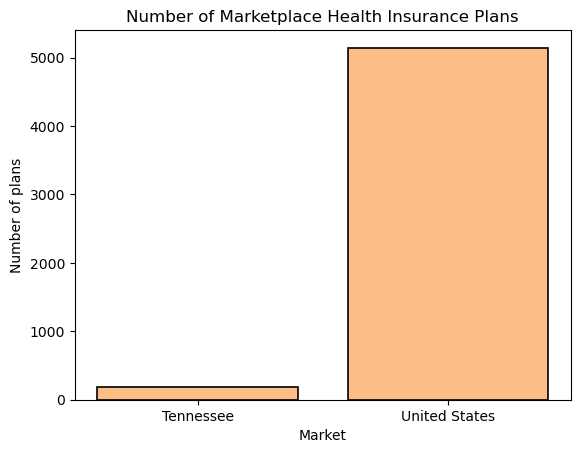

In [60]:
plt.figure()
plt.bar(plan_count['Market'], plan_count['Number of plans'], color=['#fdbe85'], edgecolor='black',linewidth=1.2)
plt.title('Number of Marketplace Health Insurance Plans')
plt.ylabel('Number of plans')
plt.xlabel('Market')

plt.show()

In [15]:
# Count plans by insurer

In [16]:
tn_top_issuers = (tn_plans['issuermarketplacemarketingname'].value_counts().head(5))
tn_top_issuers

issuermarketplacemarketingname
BlueCross BlueShield of Tennessee    504
Oscar Insurance Company               81
Ambetter of Tennessee                 76
UnitedHealthcare                      62
Cigna Healthcare                      54
Name: count, dtype: int64

In [36]:
tn_df = tn_top_issuers.reset_index()
tn_df.columns = ['Insurer', 'Number of Plans']

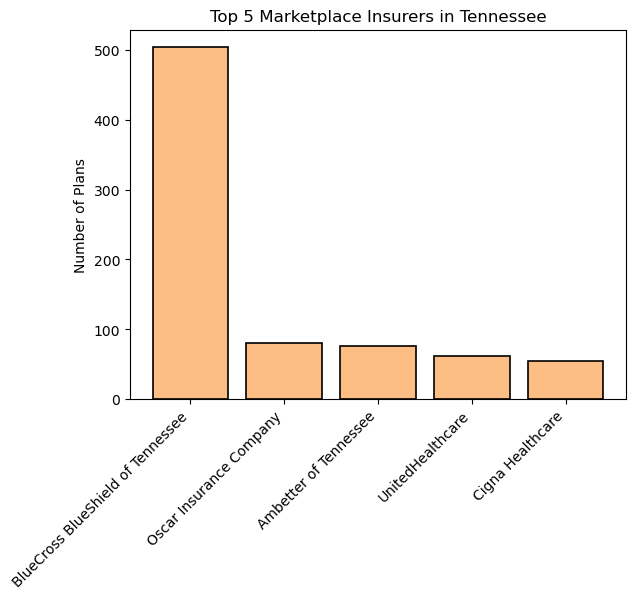

In [56]:
plt.figure()
plt.bar(tn_df['Insurer'], tn_df['Number of Plans'], color=['#fdbe85'], edgecolor='black',linewidth=1.2)
plt.title('Top 5 Marketplace Insurers in Tennessee')
plt.ylabel('Number of Plans')
plt.xticks(rotation=45, ha='right')
plt.show()

In [17]:
us_top_issuers = (us_plans['issuermarketplacemarketingname'].value_counts().head(5))
us_top_issuers

issuermarketplacemarketingname
Blue Cross and Blue Shield of Texas    2661
UnitedHealthcare                       1452
Oscar Insurance Company                1144
Medica                                 1035
Anthem Blue Cross and Blue Shield       696
Name: count, dtype: int64

In [44]:
us_df = us_top_issuers.reset_index()
us_df.columns = ['Insurer', 'Number of Plans']

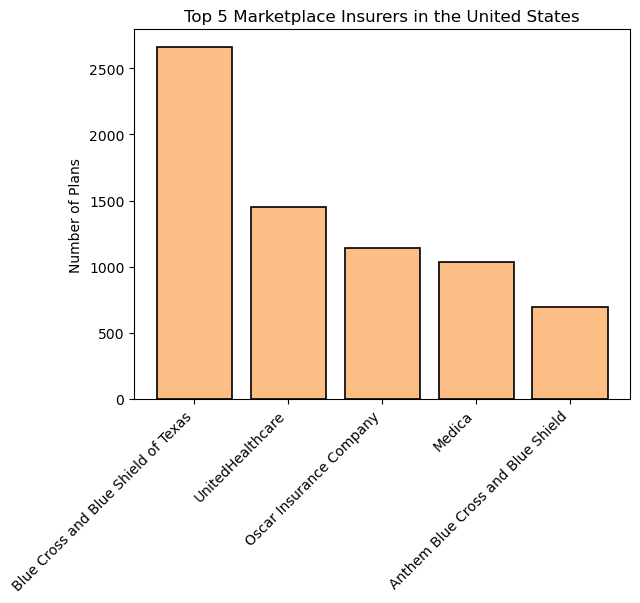

In [58]:
plt.figure()
plt.bar(us_df['Insurer'], us_df['Number of Plans'], color=['#fdbe85'], edgecolor='black',linewidth=1.2)
plt.title('Top 5 Marketplace Insurers in the United States')
plt.ylabel('Number of Plans')
plt.xticks(rotation=45, ha='right')
plt.show()

The Tennessee marketplace offers significantly fewer health insurance plans compared to the national market. This suggests that consumers in Tennessee may face more limited plan choices than consumers nationwide.

In [ ]:
# Compare Metal Level Distribution

In [50]:
tn_metal = tn_plans['metallevel'].value_counts(normalize=True) * 100
tn_metal

metallevel
Silver             50.231481
Expanded Bronze    20.833333
Gold               14.814815
Bronze              8.333333
Low                 3.356481
High                1.967593
Platinum            0.462963
Name: proportion, dtype: float64

In [52]:
us_metal = us_plans['metallevel'].value_counts(normalize=True) * 100
us_metal

metallevel
Silver             46.729226
Gold               21.619294
Expanded Bronze    21.138764
Low                 3.658371
Bronze              2.656512
High                2.638379
Platinum            0.879460
Catastrophic        0.679995
Name: proportion, dtype: float64